BASE MODEL DETAILS

In [ ]:
from models.pv_model import run_pvsam
from models.lcoe import calculate_lcoe_constant
import numpy as np
import pandas as pd
from capex_opex.excel_capex_opex import calc_capex_opex
from pathlib import Path
from models.csp_model import run_basic_mspt
import sys
sys.path.append(".")
from models.dispatch_opt import (
    optimize_dispatch,
    export_dispatch_to_csv,
    calculate_firm_bonus,
    plot_week_dispatch,
    plot_stack_flows,
    plot_shares_price
)
from capex_opex.capex import calculate_capex
from capex_opex.opex import calculate_opex


excel_file = Path("capex_opex/CAPEX OPEX model CSP-PV MJ2500.xlsx")
# == PV ===
desired_array_size = 183500     # kWdc
dc_to_ac_ratio=1.2,             # DC to AC ratio for PV system
# == CSP ===
P_ref = 200                     # CSP plant size in MWe
solarm = 1.5                      # Solar Multiple
eta_PB=0.40                     # PB efficiency
# == TES ===
t_TES_hours = 11                # hours of thermal energy storage capacity
max_to_grid = 100               # MWe limit
# == ECONOMIC MODEL ===
x_price = 1                     
debt = 0.8
equity = 0.2
debt_rate = 0.05
equity_rate = 0.08
tax_rate = 0.25
lifetime_years = 30
construction_years = 2
# == MISC ===
dist_to_grid = 0                # km
dist_to_road = 0                # km
dist_to_gas = 0                 # km
dist_to_water = 0               # km
other_comp = 0                  # dummy variable for other component size

df_pv, pv_summary, pv_obj, annual_energy_kwh, land_area_m2, name_plate_kwdc = run_pvsam(
    system_kwargs=dict(
        desired_array_size=desired_array_size,  
        dc_to_ac_ratio=dc_to_ac_ratio,
    )
)

df_csp, csp_summary, mspt = run_basic_mspt(
    P_ref=P_ref,
    solarm=solarm,
)

q_csp = df_csp['P_rec_MWt_calculated'].tolist()  
e_pv  = (df_pv['AC_kWh'] / 1000).tolist() 

res, model, E_cap, PV_to_heater_max,CF_hybrid,CF_pb, E_hybrid,E_pv_grid,E_pb_elec = optimize_dispatch(
    q_csp,e_pv,eta_PB=eta_PB,x_price=x_price,max_to_grid=max_to_grid,allow_spill=True,     
    objective_mode="revenue",                                   # <---: "revenue" or "cf_hybrid" or "cf_pb" (optional)                       
    PB_e_max=csp_summary.get("NetCapacity_MWe"),
    E_cap=(csp_summary.get("NetCapacity_MWe")*t_TES_hours)/eta_PB,
    solarm=solarm,
    )  

bonus = calculate_firm_bonus(res, base_price=1, bonus_rate=0.2, margin=0.05, min_hours=3)

inputs = {
    "PB Installed Capacity (Gross)":            csp_summary.get("NetCapacity_MWe")*1000,                # kW
    "Solar Field Aperture Area (Mirror Area)":  csp_summary.get("Solar_Field_Area_m2"),                 # m2
    "Thermal Energy Storage Capacity ":         E_cap,
    "Receiver Power (Max Rated)":               csp_summary.get("Receiver_Design_MWt"),                 # MW 0 if Parabolic Trough
    "Tower Height (w/o Receiver)":              csp_summary.get("Tower_Height_m"),                      # m
    # "Electric Heater Thermal Power (Max Rated)":csp_summary.get("Electric_Heater_Power_MWt"),         # MWt
    "Electric Heater Thermal Power (Max Rated)":PV_to_heater_max*1000,
    "Land Area CSP":                            csp_summary.get("Land_Area_acre") * 4046.86,            # m2
    "PV Installed Capacity":                    name_plate_kwdc *1000,                                  # Wdc 
    "Battery Pack Power (Max Rated)":           0,                                                    # MW bess_energy_mwh or 
    "Battery Pack Capacity":                    0,                                                      # MWh-e bess_energy_mwh or 
    "Battery Annual Generation (for OPEX)":     0,                                                    # GWh/y
    "Land Area PV":                             land_area_m2,                                           # m2
    "CSP Annual Generation (for OPEX)":         csp_summary.get("Annual_kWh") / 1000000,                # GWh/y
    "Distance to Grid ":                        dist_to_grid,
    "Distance to Road":                         dist_to_road,
    "Distance to Gas":                          dist_to_gas,
    "Distance to Water":                        dist_to_water,
    "Other Component Size":                     other_comp,
}

scaling_data = [
    ["CSP Power Block", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP BOP",  csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP SF", csp_summary.get("Solar_Field_Area_m2")],
    ["CSP TES", E_cap],
    ["CSP Receiver", csp_summary.get("Receiver_Design_MWt")],
    ["CSP Tower", csp_summary.get("Tower_Height_m")],
    ["CSP Site Preparations / Civil works", csp_summary.get("Land_Area_acre") * 4046.86],
    ["Electric Heater", PV_to_heater_max*1000],
    ["Grid Connection Costs", dist_to_grid],
    ["Road Costs", dist_to_road],
    ["Gas Pipeline Costs", dist_to_gas],
    ["Water Pipeline Costs", dist_to_water],
    ["Battery Pack - Power", 0],
    ["Battery Pack - Capacity", 0],
    ["Other Component", other_comp],
    ["PV Modules", name_plate_kwdc *1000],
    ["PV Inverters", name_plate_kwdc *1000],
    ["PV BOS (except Inverters)", name_plate_kwdc *1000],
    ["PV additional rack (SA tracking)", name_plate_kwdc *1000],
    ["PV Site Preperations / Civil works", land_area_m2]
]

opex_scaling_data = [
    ["CSP Admin/Finance & Management", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Plant Operations Labor", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Plant Maintenance Labor", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Solar Field Maintenance Labor", csp_summary.get("Solar_Field_Area_m2")],
    ["CSP Subcontracted Services", csp_summary.get("Annual_kWh") / 1000000],
    ["CSP Electricity Use", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Water Use", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Machinery", csp_summary.get("NetCapacity_MWe")*1000],
    ["CSP Spare Parts", csp_summary.get("Annual_kWh") / 1000000],
    ["Battery Pack - Fixed OPEX", 0],
    ["Battery Pack - Variable OPEX", 0],
    ["Other OPEX", 0],
]

scaling_df = pd.DataFrame(scaling_data, columns=["Component", "Scaling Param"])
opex_scaling_df = pd.DataFrame(opex_scaling_data, columns=["Component", "Scaling Param"])
capex_musd, df_capex, pv_components = calculate_capex(scaling_df)
capex_musd =float(capex_musd)
pv_capex = df_capex.loc[df_capex["Component"].isin(pv_components), "Scaled Cost (MUSD)"].sum()
opex_musd, df = calculate_opex(opex_scaling_df, pv_capex)
opex_musd = float(opex_musd)

wacc = (debt * debt_rate * (1 - tax_rate)) + (equity * equity_rate)
lcoe = calculate_lcoe_constant(capex_musd, opex_musd, E_hybrid,lifetime_years,wacc)
sigma_capex = sum((capex_musd*10**6) / (construction_years*(1 + wacc)**t) for t in range(0, construction_years - 1))
sigma_opex = sum(1 / (1 + wacc)**t for t in range(1,lifetime_years + construction_years -1))
A = sigma_capex / sigma_opex
PPA = (A + opex_musd*10**6) / bonus['total_revenue_with_bonus']
annual_tot_revenue = PPA * bonus['total_revenue_with_bonus']

print("\n--- PV Simulation Summary ---")
for k, v in pv_summary.items():
    print(f"{k:25s}: {v:,.2f}") 

print("\n--- CSP Simulation Summary ---")
for k, v in csp_summary.items():
    print(f"{k:25s}: {v:,.2f}") 

print("\n--- TES & Heater ---")
print(f"Electric_Heater_Power_MWt : {PV_to_heater_max:,.2f}")
print(f"Tes_Capacity_MWh : {E_cap:,.2f}")
print(f"TES_Hours : {t_TES_hours:,.1f}")


print("\n--- CAPACITY FACTOR ---")
print(f"PV CSP Cap Factor : {CF_hybrid:,.2f}")
print(f"CSP Cap Factor : {CF_pb:,.2f}")


revenue = res.get("revenue_total", None)
if revenue is None:
    # compute from outputs
    price = np.array(res["price_profile"], dtype=float)           # EUR/MWh
    export = (np.array(res["pv_to_grid_MWe"], dtype=float) +
              np.array(res["pb_electric_MWe"], dtype=float))      # MWe
    dt_h = 1.0  # adjust if you solved with other dt
    revenue = float((price * export * dt_h).sum())

print("\n--- Dispatch Optimization Results ---")
print(f"Revenue (Σ α*E[t]): {revenue:,.2f} MWh")
print(f"💰 Bonus revenue (Σ α*E[t]): {bonus['bonus_revenue']:,.2f} MWh")
print(f"💰 Total revenue (with bonus) (Σ α*E[t]): {bonus['total_revenue_with_bonus']:,.2f} MWh")
print(f"✅ Firm operation hours: {bonus['firm_hours']} hours")

print("\n--- CAPEX/OPEX Input Parameters ---")
for key, val in inputs.items():
    try:
        print(f"{key:45s}: {val:,.3f}")
    except (TypeError, ValueError):
        print(f"{key:45s}: {val}")

print("\n--- CAPEX/OPEX Output Calculation ---")
print(f"Capex : {capex_musd:,.2f} MUSD")
print(f"Opex : {opex_musd:,.2f} MUSD")
print(f"Present Value Factor (S): {sigma_capex:,.2f}")
print(f"A value: {A:,.2f}")
print(f"PPA value: {PPA:,.2f} USD/MWh or {PPA/1000:,.4f} USD/kWh")
print(f"LCOE Hybrid USD: {lcoe:,.2f}")
print(f"Annual Revenue: {annual_tot_revenue/1000000:,.2f} MUSD" )

export_dispatch_to_csv(res, "output_data")



In [ ]:
plot_week_dispatch(res, week_start_hour=4104, hours=168, save_as="viz/summer_elc.png")
plot_stack_flows(res, start_hour=4104, hours=168, save_as="viz/summer_heat.png")
plot_shares_price(res,
                                base_price=1.0,
                                bins=[0, 0.5, 1.0, np.inf],
                                bin_labels=["0.5×", "1×", "2×"],
                                dt=1.0,
                                save_as="viz/tariff_shceme_share.png")

In [ ]:
from capex_opex.capex import calculate_capex
from capex_opex.opex import calculate_opex
import pandas as pd


# scaling_data = [
#     ["CSP Power Block", 100000],
#     ["CSP BOP",  100000],
#     ["CSP SF", 507597.5],
#     ["CSP TES", 3271.3],
#     ["CSP Receiver", 200],
#     ["CSP Tower", 200],
#     ["CSP Site Preparations / Civil works", 2000000],
#     ["Electric Heater", 200000],
#     ["Grid Connection Costs", 4],
#     ["Road Costs", 2],
#     ["Gas Pipeline Costs", 5],
#     ["Water Pipeline Costs", 10],
#     ["Battery Pack - Power", 150],
#     ["Battery Pack - Capacity", 300],
#     ["Other Component", 0],
#     ["PV Modules", 270327760],
#     ["PV Inverters", 270327760],
#     ["PV BOS (except Inverters)", 270327760],
#     ["PV additional rack (SA tracking)", 270327760],
#     ["PV Site Preperations / Civil works", 1000000]
# ]

scaling_df = pd.DataFrame(scaling_data, columns=["Component", "Scaling Param"])
opex_scaling_df = pd.DataFrame(opex_scaling_data, columns=["Component", "Scaling Param"])
capex_result, df_capex, pv_components = calculate_capex(scaling_df)
pv_capex = df_capex.loc[df_capex["Component"].isin(pv_components), "Scaled Cost (MUSD)"].sum()
opex_result = calculate_opex(opex_scaling_df, pv_capex)


NSGA SIMULATION

In [1]:
from nsga_model_v3 import main
pop, hof = main(seed=123, pop_size=40, ngen=20, cxpb=0.9, mutpb=0.3,
                log_csv="ga_trials.csv", n_jobs=4)

Gen   1/20 | min PPA: 38.179 USD/MWh | best CF: 0.7655
Gen   2/20 | min PPA: 38.179 USD/MWh | best CF: 0.7655
Gen   3/20 | min PPA: 38.174 USD/MWh | best CF: 0.7655
Gen   4/20 | min PPA: 38.174 USD/MWh | best CF: 0.7902
Gen   5/20 | min PPA: 37.706 USD/MWh | best CF: 0.8056
Gen   6/20 | min PPA: 37.520 USD/MWh | best CF: 0.8056
Gen   7/20 | min PPA: 37.520 USD/MWh | best CF: 0.8061
Gen   8/20 | min PPA: 37.520 USD/MWh | best CF: 0.8093
Gen   9/20 | min PPA: 37.520 USD/MWh | best CF: 0.8093
Gen  10/20 | min PPA: 37.520 USD/MWh | best CF: 0.8096
Gen  11/20 | min PPA: 37.093 USD/MWh | best CF: 0.8096
Gen  12/20 | min PPA: 37.093 USD/MWh | best CF: 0.8096
Gen  13/20 | min PPA: 37.093 USD/MWh | best CF: 0.8096
Gen  14/20 | min PPA: 37.093 USD/MWh | best CF: 0.8096
Gen  15/20 | min PPA: 37.002 USD/MWh | best CF: 0.8096
Gen  16/20 | min PPA: 37.002 USD/MWh | best CF: 0.8099
Gen  17/20 | min PPA: 37.002 USD/MWh | best CF: 0.8113
Gen  18/20 | min PPA: 37.002 USD/MWh | best CF: 0.8113
Gen  19/20

CHECKING RESULT

In [ ]:
from model_system import run_hybrid_summary

results, res, bonus = run_hybrid_summary(desired_array_size=183500 , 
                             P_ref=102.0, 
                             t_TES_hours=9.0 ,
                             solarm=1.5,

                             )
    

In [ ]:
from model_system import run_hybrid_summary

results, res, bonus = run_hybrid_summary(desired_array_size=183500 , 
                             P_ref=102.0, 
                             t_TES_hours=9.0 ,
                             solarm=1.5,
                             )
    


In [ ]:
print("\n--- Hybrid System Summary ---")
for key, val in results.items():
    try:
        print(f"{key:25s}: {val:,.2f}")
    except (TypeError, ValueError):
        print(f"{key:25s}: {val}")
print("\n--- Bonus Summary ---")
print(f"{"E to grid":25s}: {(results["PV_to_Grid_MWh"]+results["CSP_to_Grid_MWh"]):,.2f}")
print(f"{"alpha * E to grid":25s}: {bonus["base_revenue"]:,.2f}")
print(f"{"bonus":25s}: {bonus["bonus_revenue"]:,.2f}")
print(f"{"alpha * E to grid + bonus":25s}: {bonus["total_revenue_with_bonus"]:,.2f}")


In [2]:
from models.dispatch_opt import plot_stack_flows, plot_stack_flows_elc, plot_shares_price

plot_stack_flows    (res, start_hour=4104, hours=168, save_as=None)
plot_stack_flows_elc(res, start_hour=4104, hours=168, save_as=None)
plot_stack_flows    (res, start_hour=1096, hours=168, save_as=None)
plot_stack_flows_elc(res, start_hour=1096, hours=168, save_as=None)
plot_shares_price   (res, base_price=1.0, bins=[0, 0.5, 1.0, 2], bin_labels=["0.5× (night price)", "1× (base price)", "2× (evening peak price)"])


NameError: name 'res' is not defined

PLOT PARETO FRONT


=== Chosen trade-off point ===
gen                                                 13
desired_array_size                            299000.0
P_ref                                            123.0
t_TES_hours                                       12.0
solarm                                             1.5
PPA_USD_per_MWh                              39.823601
CF_hybrid                                     0.716686
CF_pb                                         0.292251
LCOE                                        109.875836
Annual_Revenue_USD                     38926607.572257
PV_to_Grid_MWh                            312922.78597
CSP_to_Grid_MWh                          314894.163782
fitness_PPA                                  39.823601
fitness_CF                                    0.716686
status                                              ok
note                               offspring; n_jobs=4
timestamp             2025-11-21T21:34:33.650905+00:00
Name: 500, dtype: object
Saved pl

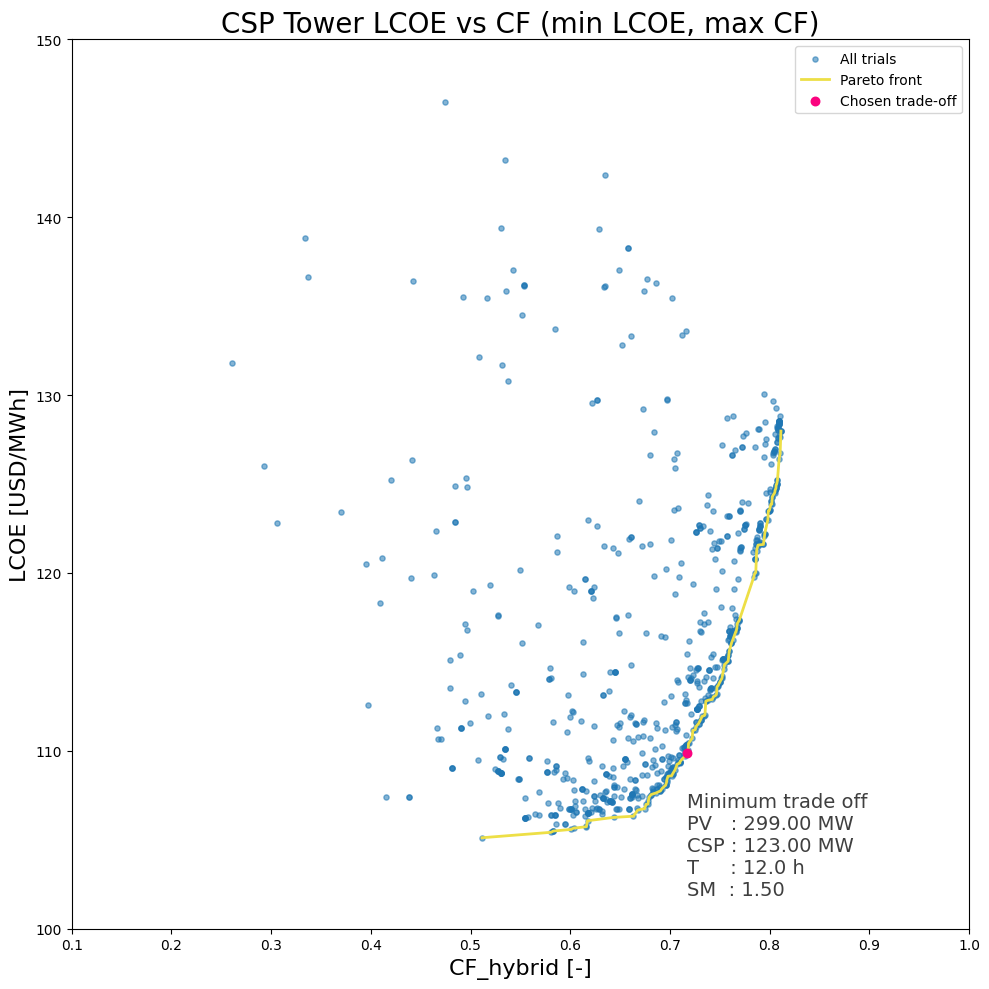

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =======================
# CONFIG — EDIT THIS PART
# =======================
CSV_PATH = "ga_trials.csv"         # path to your CSV
METRIC   = "LCOE"                   # "PPA" or "LCOE"
METHOD   = "utopia"                # "utopia" or "weighted"
WEIGHT   = 0                   # only for METHOD="weighted" (0..1): weight on CF vs metric
SAVE_PNG = "tradeoff_plot.png"     # set to None to skip saving

# Axis ranges (set None to auto)
XLIM = (0.10, 1)                # CF range (x-axis), e.g. (0.3, 0.8); or None
YLIM = (100, 150)                         # metric (y-axis) range, e.g. (20, 80); or None
POINT_SIZE = 14                    # scatter size

# =======================
# Helpers
# =======================
def num(x):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
    except Exception:
        pass
    return np.nan

def normalize_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].apply(num)
    return df

def ensure_columns(df):
    # harmonize names
    if "CF_hybrid" not in df and "CF" in df: df["CF_hybrid"] = df["CF"]
    if "PPA_USD_per_MWh" not in df and "PPA" in df: df["PPA_USD_per_MWh"] = df["PPA"]
    return df

def filter_valid(df, need_lcoe=False):
    cols = ["CF_hybrid", "PPA_USD_per_MWh"] + (["LCOE"] if need_lcoe else [])
    base = df.dropna(subset=[c for c in cols if c in df.columns])
    if "status" in base.columns:
        base = base[base["status"] == "ok"]
    return base

def pareto_max_cf_min_metric(df, metric_col):
    """Return Pareto frontier (maximize CF, minimize metric)."""
    # Sort by CF desc, metric asc
    order = np.lexsort((df[metric_col].values, -df["CF_hybrid"].values))
    xs, ys = df["CF_hybrid"].values[order], df[metric_col].values[order]
    keep_idx_sorted = []
    best_y = np.inf
    for i, (x, y) in enumerate(zip(xs, ys)):
        if y < best_y:
            best_y = y
            keep_idx_sorted.append(i)
    idx = df.index.values[order][keep_idx_sorted]
    front = df.loc[idx].copy()
    front.sort_values(["CF_hybrid", metric_col], ascending=[True, True], inplace=True)
    return front

def pick_tradeoff(front, metric_col, method="utopia", weight=0.5):
    """
    Choose one compromise point from the Pareto front.

    method="utopia": minimize Euclidean distance to the utopia point:
        utopia CF = max CF on the front, utopia metric = min metric on the front.
        Normalize each axis to [0,1] before distance.

    method="weighted": maximize W*CF_norm - (1-W)*Metric_norm
        (CF normalized high=1 good, Metric normalized low=1 good)
    """
    if front.empty:
        return None

    cf = front["CF_hybrid"].values
    m  = front[metric_col].values

    # normalize to [0,1]
    cf_min, cf_max = np.nanmin(cf), np.nanmax(cf)
    m_min,  m_max  = np.nanmin(m),  np.nanmax(m)
    # guard zero division
    cf_norm = (cf - cf_min) / (cf_max - cf_min) if cf_max > cf_min else np.zeros_like(cf)
    # for metric (lower is better), invert so "good" ~ 1
    m_norm  = (m_max - m) / (m_max - m_min) if m_max > m_min else np.ones_like(m)

    if method == "utopia":
        # Utopia is (CF_norm=1, M_norm=1). Minimize distance.
        dist2 = (1 - cf_norm)**2 + (1 - m_norm)**2
        k = int(np.argmin(dist2))
    elif method == "weighted":
        w = float(weight)
        score = w * cf_norm + (1 - w) * m_norm
        k = int(np.argmax(score))
    else:
        raise ValueError("METHOD must be 'utopia' or 'weighted'.")

    return front.iloc[k]

def plot_tradeoff(all_df, front_df, chosen_row, metric_col, xlim=None, ylim=None, save_png=None):
    plt.figure(figsize=(10,10))

    # All trials
    plt.scatter(
        all_df["CF_hybrid"], all_df[metric_col],
        s=POINT_SIZE, alpha=0.55,
        label="All trials", color='#1f77b4'
    )

    # Pareto front
    if not front_df.empty:
        plt.plot(
            front_df["CF_hybrid"], front_df[metric_col],
            lw=2, label="Pareto front", color="#eddf46"
        )

    # Chosen trade-off point
    if chosen_row is not None:
        plt.scatter(
            [chosen_row["CF_hybrid"]],
            [chosen_row[metric_col]],
            zorder=12,
            s=150,
            marker=".",
            # edgecolor="k",
            label="Chosen trade-off",
            color="#fb037f",
        )
        plt.text(
            chosen_row["CF_hybrid"],
            chosen_row[metric_col] * 0.98,
            f"Minimum trade off \n"
            f"PV   : {chosen_row['desired_array_size']/1000:.2f} MW\n"
            f"CSP : {chosen_row['P_ref']:.2f} MW\n"
            f"T     : {chosen_row['t_TES_hours']:.1f} h\n"
            f"SM  : {chosen_row['solarm']:,.2f}\n",
            fontsize=14,
            ha="left",
            va="top",
            color="#3F3F3F"
        )

    # >>> NEW PART: mark minimum PPA on the Pareto front <<<
    if (not front_df.empty) and (metric_col == "PPA_USD_per_MWh"):
        min_idx = front_df[metric_col].idxmin()
        min_row = front_df.loc[min_idx]

        plt.scatter(
            [min_row["CF_hybrid"]],
            [min_row[metric_col]],
            zorder=11,
            s=220,
            marker="+",
            # edgecolor="k",
            label="Minimum X",
            color="#d40074",
        )
        plt.text(
            min_row["CF_hybrid"],
            min_row[metric_col] * 0.98,    #offset downward
            f"Minimum X\n"
            f"PV   : {min_row['desired_array_size']/1000:.2f} MW\n"
            f"CSP : {min_row['P_ref']:.2f} MW\n"
            f"T     : {min_row['t_TES_hours']:.1f} h\n"
            f"SM  : {min_row['solarm']:,.2f}\n",
            fontsize=12,
            ha="left",
            va="top",
            color="#282828",
            
        )
    # <<< END NEW PART >>>

    plt.xlabel("CF_hybrid [-]", size=16)
    ylabel = "X [USD/MWh]" if metric_col == "PPA_USD_per_MWh" else "LCOE [USD/MWh]"
    plt.ylabel(ylabel, size=16)
    plt.title(f"CSP Tower {ylabel.split()[0]} vs CF (min {ylabel.split()[0]}, max CF)", size=20)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.legend()
    plt.tight_layout()

    if save_png:
        Path(save_png).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_png, dpi=150)
        print(f"Saved plot → {save_png}")

    plt.show()

# =======================
# Run
# =======================
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path)
df = ensure_columns(df)
df = normalize_numeric(df, ["CF_hybrid", "PPA_USD_per_MWh", "LCOE"])

metric_col = "PPA_USD_per_MWh" if METRIC.upper() == "PPA" else "LCOE"
need_lcoe = (metric_col == "LCOE")

valid = filter_valid(df, need_lcoe=need_lcoe)
if valid.empty:
    raise SystemExit("No valid rows found (check column names/values).")

front = pareto_max_cf_min_metric(valid, metric_col)
chosen = pick_tradeoff(front, metric_col, method=METHOD, weight=WEIGHT)

# Print the chosen point (full row) so you can copy parameters
print("\n=== Chosen trade-off point ===")
if chosen is not None:
    with pd.option_context('display.max_columns', None):
        print(chosen)
else:
    print("No point chosen (empty frontier).")

# Plot
plot_tradeoff(valid, front, chosen, metric_col, xlim=XLIM, ylim=YLIM, save_png=SAVE_PNG)



=== Chosen trade-off point ===
gen                                                 17
desired_array_size                            300000.0
P_ref                                            200.0
t_TES_hours                                       12.0
solarm                                             1.7
PPA_USD_per_MWh                               47.99694
CF_hybrid                                     0.810567
CF_pb                                         0.226532
LCOE                                        128.806057
Annual_Revenue_USD                     51769492.517638
PV_to_Grid_MWh                           313172.689768
CSP_to_Grid_MWh                          396884.285342
fitness_PPA                                   47.99694
fitness_CF                                    0.810567
status                                              ok
note                               offspring; n_jobs=4
timestamp             2025-11-21T22:06:45.386163+00:00
Name: 647, dtype: object
Saved pl

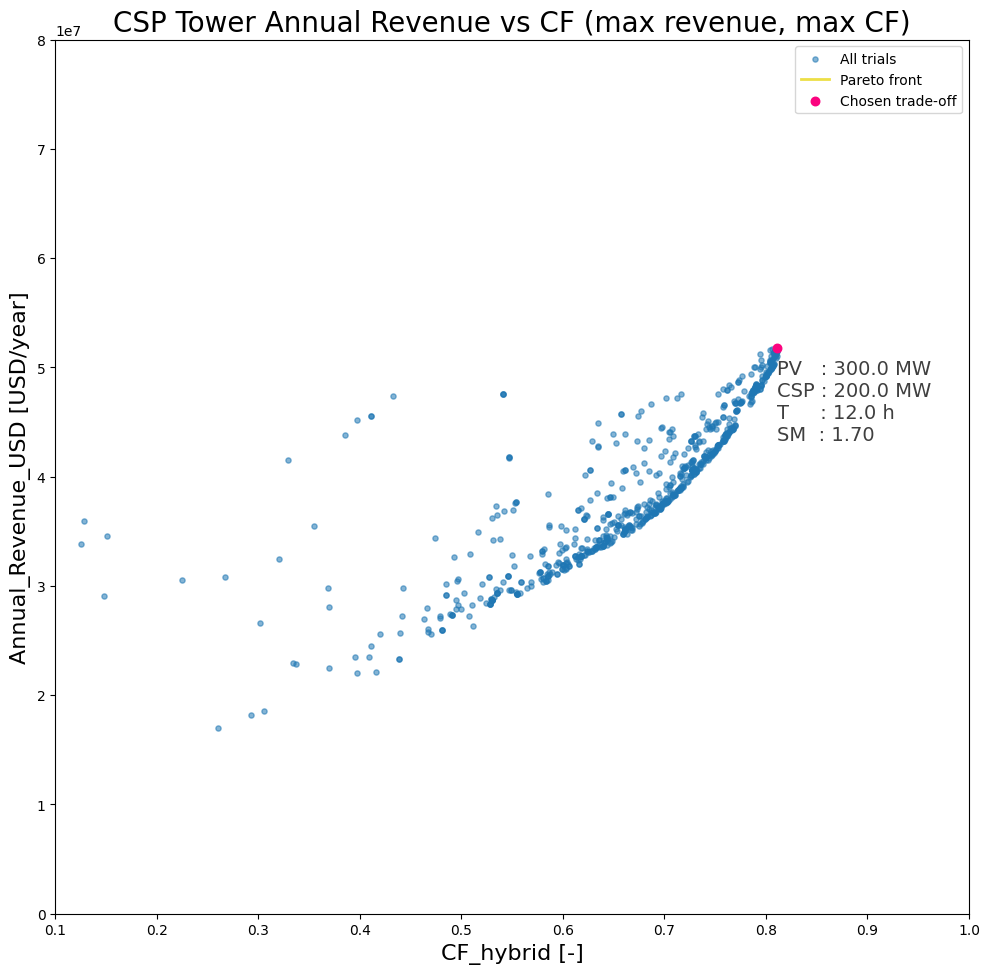

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =======================
# CONFIG
# =======================
CSV_PATH = "ga_trials.csv"          # path to your CSV
METHOD   = "utopia"                 # "utopia" or "weighted"
WEIGHT   = 1                      # only for METHOD="weighted" (0..1): weight on CF vs revenue
SAVE_PNG = "tradeoff_revenue.png"   # set to None to skip saving

# Axis ranges (set None to auto)
XLIM = (0.1, 1)                         # e.g. (0.2, 0.9) or None
YLIM = (0, 0.8e8)                         # e.g. (0, 1e8) or None
POINT_SIZE = 14                     # scatter size

# =======================
# Helpers
# =======================
def num(x):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
    except Exception:
        pass
    return np.nan

def normalize_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].apply(num)
    return df

def ensure_columns(df):
    # harmonize names
    if "CF_hybrid" not in df and "CF" in df:
        df["CF_hybrid"] = df["CF"]

    # Try to harmonize annual revenue name
    if "Annual_Revenue_USD" not in df:
        if "annual_revenue_USD" in df:
            df["Annual_Revenue_USD"] = df["annual_revenue_USD"]
        elif "annual_revenue" in df:
            df["Annual_Revenue_USD"] = df["annual_revenue"]
    return df

def filter_valid(df):
    cols = ["CF_hybrid", "Annual_Revenue_USD"]
    cols = [c for c in cols if c in df.columns]
    base = df.dropna(subset=cols)
    if "status" in base.columns:
        base = base[base["status"] == "ok"]
    return base

def pareto_max_cf_max_metric(df, metric_col):
    """
    Pareto frontier for maximizing CF and maximizing metric (revenue).
    """
    # Sort by CF desc, metric desc
    order = np.lexsort((-df[metric_col].values, -df["CF_hybrid"].values))
    xs, ys = df["CF_hybrid"].values[order], df[metric_col].values[order]

    keep_idx_sorted = []
    best_y = -np.inf
    for i, (x, y) in enumerate(zip(xs, ys)):
        if y > best_y:
            best_y = y
            keep_idx_sorted.append(i)

    idx = df.index.values[order][keep_idx_sorted]
    front = df.loc[idx].copy()
    # sort for plotting (CF ascending)
    front.sort_values(["CF_hybrid", metric_col], ascending=[True, False], inplace=True)
    return front

def pick_tradeoff(front, metric_col, method="utopia", weight=0.5):
    """
    Choose one compromise point from the Pareto front.

    method="utopia": minimize distance to utopia point: (max CF, max metric).
    method="weighted": maximize W*CF_norm + (1-W)*Metric_norm.
    """
    if front.empty:
        return None

    cf = front["CF_hybrid"].values
    m  = front[metric_col].values

    # normalize to [0,1]
    cf_min, cf_max = np.nanmin(cf), np.nanmax(cf)
    m_min,  m_max  = np.nanmin(m),  np.nanmax(m)

    cf_norm = (cf - cf_min) / (cf_max - cf_min) if cf_max > cf_min else np.zeros_like(cf)
    m_norm  = (m - m_min) / (m_max - m_min) if m_max > m_min else np.zeros_like(m)

    if method == "utopia":
        # Utopia is (1,1) in normalized space
        dist2 = (1 - cf_norm)**2 + (1 - m_norm)**2
        k = int(np.argmin(dist2))
    elif method == "weighted":
        w = float(weight)
        score = w * cf_norm + (1 - w) * m_norm
        k = int(np.argmax(score))
    else:
        raise ValueError("METHOD must be 'utopia' or 'weighted'.")

    return front.iloc[k]

def plot_tradeoff(all_df, front_df, chosen_row, metric_col, xlim=None, ylim=None, save_png=None):
    plt.figure(figsize=(10,10))

    plt.scatter(
        all_df["CF_hybrid"], all_df[metric_col],
        s=POINT_SIZE, alpha=0.55, label="All trials", color='#1f77b4'
    )

    if not front_df.empty:
        plt.plot(
            front_df["CF_hybrid"], front_df[metric_col],
            lw=2, label="Pareto front", color="#eddf46"
        )

    if chosen_row is not None:
        plt.scatter(
            [chosen_row["CF_hybrid"]],
            [chosen_row[metric_col]],
            zorder=10, s=150, marker=".",
            # edgecolor="k", 
            label="Chosen trade-off",
            color="#fb037f",
        )

        # Multiline label with system design
        plt.text(
            chosen_row["CF_hybrid"],
            chosen_row[metric_col] * 0.98,
            f"PV   : {chosen_row['desired_array_size']/1000:.1f} MW\n"
            f"CSP : {chosen_row['P_ref']:.1f} MW\n"
            f"T     : {chosen_row['t_TES_hours']:.1f} h\n"
            f"SM  : {chosen_row['solarm']:.2f}",
            fontsize=14,
            ha="left",
            va="top",
            color="#3F3F3F",
        )

    plt.xlabel("CF_hybrid [-]", size=16)
    plt.ylabel("Annual_Revenue_USD [USD/year]", size=16)
    plt.title("CSP Tower Annual Revenue vs CF (max revenue, max CF)", size=20)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.legend()
    plt.tight_layout()

    if save_png:
        Path(save_png).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_png, dpi=150)
        print(f"Saved plot → {save_png}")

    plt.show()

# =======================
# Run
# =======================
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path)
df = ensure_columns(df)
df = normalize_numeric(df, ["CF_hybrid", "Annual_Revenue_USD"])

metric_col = "Annual_Revenue_USD"

valid = filter_valid(df)
if valid.empty:
    raise SystemExit("No valid rows found (check column names/values).")

front = pareto_max_cf_max_metric(valid, metric_col)
chosen = pick_tradeoff(front, metric_col, method=METHOD, weight=WEIGHT)

print("\n=== Chosen trade-off point ===")
if chosen is not None:
    with pd.option_context('display.max_columns', None):
        print(chosen)
else:
    print("No point chosen (empty frontier).")

plot_tradeoff(valid, front, chosen, metric_col, xlim=XLIM, ylim=YLIM, save_png=SAVE_PNG)



=== Chosen trade-off point ===
gen                                                 19
desired_array_size                            299000.0
P_ref                                            124.0
t_TES_hours                                       12.0
solarm                                             1.6
PPA_USD_per_MWh                              40.153708
CF_hybrid                                     0.722311
CF_pb                                          0.29443
LCOE                                        110.710823
Annual_Revenue_USD                     39497061.973839
PV_to_Grid_MWh                            312922.78597
CSP_to_Grid_MWh                          319821.746416
fitness_PPA                                  40.153708
fitness_CF                                    0.722311
status                                              ok
note                               offspring; n_jobs=4
timestamp             2025-11-21T22:22:33.974540+00:00
Name: 731, dtype: object
Saved pl

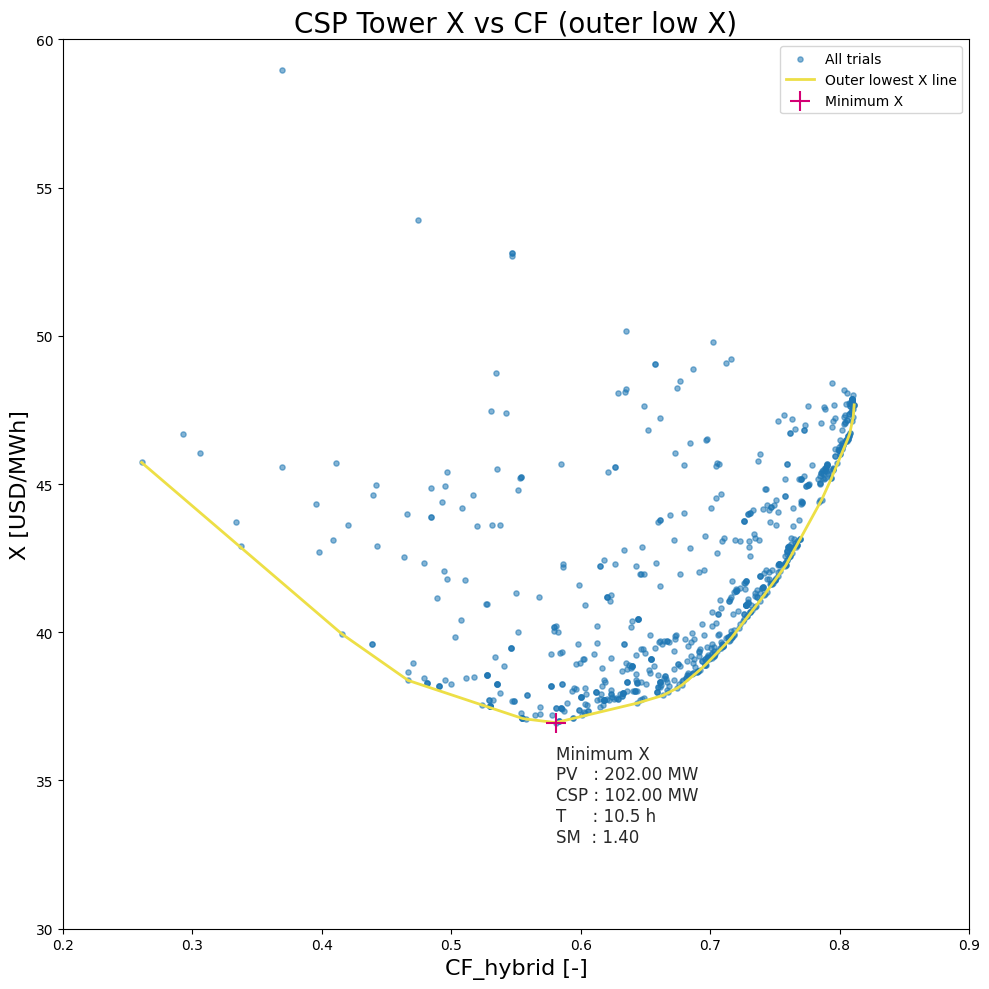

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =======================
# CONFIG — EDIT THIS PART
# =======================
CSV_PATH = "ga_trials.csv"         # path to your CSV
METRIC   = "PPA"                   # "PPA" or "LCOE"
METHOD   = "utopia"                # "utopia" or "weighted"
WEIGHT   = 0                       # only for METHOD="weighted" (0..1): weight on CF vs metric
SAVE_PNG = "tradeoff_plot.png"     # set to None to skip saving

# Axis ranges (set None to auto)
XLIM = (0.20, 0.9)                   # CF range (x-axis); or None
YLIM = (30, 60)                    # metric (y-axis) range; or None
POINT_SIZE = 14                    # scatter size

# =======================
# Helpers
# =======================
def num(x):
    try:
        v = float(x)
        if np.isfinite(v):
            return v
    except Exception:
        pass
    return np.nan

def normalize_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].apply(num)
    return df

def ensure_columns(df):
    # harmonize names
    if "CF_hybrid" not in df and "CF" in df:
        df["CF_hybrid"] = df["CF"]
    if "PPA_USD_per_MWh" not in df and "PPA" in df:
        df["PPA_USD_per_MWh"] = df["PPA"]
    return df

def filter_valid(df, need_lcoe=False):
    cols = ["CF_hybrid", "PPA_USD_per_MWh"] + (["LCOE"] if need_lcoe else [])
    base = df.dropna(subset=[c for c in cols if c in df.columns])
    if "status" in base.columns:
        base = base[base["status"] == "ok"]
    return base

def pareto_max_cf_min_metric(df, metric_col):
    """Return Pareto frontier (maximize CF, minimize metric)."""
    order = np.lexsort((df[metric_col].values, -df["CF_hybrid"].values))
    xs, ys = df["CF_hybrid"].values[order], df[metric_col].values[order]
    keep_idx_sorted = []
    best_y = np.inf
    for i, (x, y) in enumerate(zip(xs, ys)):
        if y < best_y:
            best_y = y
            keep_idx_sorted.append(i)
    idx = df.index.values[order][keep_idx_sorted]
    front = df.loc[idx].copy()
    front.sort_values(["CF_hybrid", metric_col], ascending=[True, True], inplace=True)
    return front

def pick_tradeoff(front, metric_col, method="utopia", weight=0.5):
    """
    Choose one compromise point from the Pareto front.

    method="utopia": minimize Euclidean distance to utopia point.
    method="weighted": maximize W*CF_norm + (1-W)*M_norm (M_norm high=good).
    """
    if front.empty:
        return None

    cf = front["CF_hybrid"].values
    m  = front[metric_col].values

    cf_min, cf_max = np.nanmin(cf), np.nanmax(cf)
    m_min,  m_max  = np.nanmin(m),  np.nanmax(m)

    cf_norm = (cf - cf_min) / (cf_max - cf_min) if cf_max > cf_min else np.zeros_like(cf)
    m_norm  = (m_max - m) / (m_max - m_min) if m_max > m_min else np.ones_like(m)

    if method == "utopia":
        dist2 = (1 - cf_norm)**2 + (1 - m_norm)**2
        k = int(np.argmin(dist2))
    elif method == "weighted":
        w = float(weight)
        score = w * cf_norm + (1 - w) * m_norm
        k = int(np.argmax(score))
    else:
        raise ValueError("METHOD must be 'utopia' or 'weighted'.")

    return front.iloc[k]

# -------- NEW: lower hull from "outer" low points --------
def lower_hull_from_points(df, metric_col):
    """
    Compute the lower convex hull (outer lowest boundary) of all points
    using Andrew's monotone chain algorithm.
    Returns (xs, ys) sorted by CF_hybrid ascending.
    """
    # keep only the columns we need
    tmp = df[["CF_hybrid", metric_col]].dropna().copy()
    # sort by x then y
    tmp.sort_values(["CF_hybrid", metric_col], inplace=True)
    pts = tmp.to_numpy()  # shape (N, 2) with columns [x, y]

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    lower = np.array(lower)
    xs = lower[:, 0]
    ys = lower[:, 1]
    return xs, ys
# ---------------------------------------------------------

def plot_tradeoff(all_df, front_df, chosen_row, metric_col, xlim=None, ylim=None, save_png=None):
    plt.figure(figsize=(10, 10))

    # All trials
    plt.scatter(
        all_df["CF_hybrid"], all_df[metric_col],
        s=POINT_SIZE, alpha=0.55,
        label="All trials", color='#1f77b4'
    )

    # ====== OUTER LOWEST LINE (using lower hull points) ======
    xs_line, ys_line = lower_hull_from_points(all_df, metric_col)

    # clip to xlim if given
    if xlim is not None:
        mask = (xs_line >= xlim[0]) & (xs_line <= xlim[1])
        xs_line = xs_line[mask]
        ys_line = ys_line[mask]

    plt.plot(
        xs_line, ys_line,
        lw=2,
        color="#eddf46",
        label="Outer lowest X line",
    )
    # =========================================================

    # Chosen trade-off point (from Pareto)
    # if chosen_row is not None:
    #     plt.scatter(
    #         [chosen_row["CF_hybrid"]],
    #         [chosen_row[metric_col]],
    #         zorder=12,
    #         s=150,
    #         marker=".",
    #         label="Minimum trade off",
    #         color="#fb037f",
    #     )
    #     plt.text(
    #         chosen_row["CF_hybrid"],
    #         chosen_row[metric_col] * 0.98,
    #         f"Minimum trade off \n"
    #         f"PV   : {chosen_row['desired_array_size']/1000:.2f} MW\n"
    #         f"CSP : {chosen_row['P_ref']:.2f} MW\n"
    #         f"T     : {chosen_row['t_TES_hours']:.1f} h\n"
    #         f"SM  : {chosen_row['solarm']:,.2f}\n",
    #         fontsize=14,
    #         ha="left",
    #         va="top",
    #         color="#3F3F3F"
    #     )

    # Mark global minimum PPA point
    if metric_col == "PPA_USD_per_MWh":
        min_idx = all_df[metric_col].idxmin()
        min_row = all_df.loc[min_idx]

        plt.scatter(
            [min_row["CF_hybrid"]],
            [min_row[metric_col]],
            zorder=11,
            s=220,
            marker="+",
            label="Minimum X",
            color="#d40074",
        )
        plt.text(
            min_row["CF_hybrid"],
            min_row[metric_col] * 0.98,
            f"Minimum X\n"
            f"PV   : {min_row['desired_array_size']/1000:.2f} MW\n"
            f"CSP : {min_row['P_ref']:.2f} MW\n"
            f"T     : {min_row['t_TES_hours']:.1f} h\n"
            f"SM  : {min_row['solarm']:,.2f}\n",
            fontsize=12,
            ha="left",
            va="top",
            color="#282828",
        )

    plt.xlabel("CF_hybrid [-]", size=16)
    ylabel = "X [USD/MWh]" if metric_col == "PPA_USD_per_MWh" else "LCOE [USD/MWh]"
    plt.ylabel(ylabel, size=16)
    plt.title(f"CSP Tower {ylabel.split()[0]} vs CF (outer low {ylabel.split()[0]})", size=20)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.legend()
    plt.tight_layout()

    if save_png:
        Path(save_png).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_png, dpi=150)
        print(f"Saved plot → {save_png}")

    plt.show()

# =======================
# Run
# =======================
csv_path = Path(CSV_PATH)
df = pd.read_csv(csv_path)
df = ensure_columns(df)
df = normalize_numeric(df, ["CF_hybrid", "PPA_USD_per_MWh", "LCOE"])

metric_col = "PPA_USD_per_MWh" if METRIC.upper() == "PPA" else "LCOE"
need_lcoe = (metric_col == "LCOE")

valid = filter_valid(df, need_lcoe=need_lcoe)
if valid.empty:
    raise SystemExit("No valid rows found (check column names/values).")

front = pareto_max_cf_min_metric(valid, metric_col)
chosen = pick_tradeoff(front, metric_col, method=METHOD, weight=WEIGHT)

print("\n=== Chosen trade-off point ===")
if chosen is not None:
    with pd.option_context('display.max_columns', None):
        print(chosen)
else:
    print("No point chosen (empty frontier).")

plot_tradeoff(valid, front, chosen, metric_col, xlim=XLIM, ylim=YLIM, save_png=SAVE_PNG)
